Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Campaign     TV  Radio  Newspaper  Sales
0    camp1  230.1   37.8       69.2   22.1
1    camp2   44.5   39.3       45.1   10.4
2    camp3   17.2   45.9       69.3   12.0
3    camp4  151.5   41.3       58.5   16.5
4    camp5  180.8   10.8       58.4   17.9

Dataset shape: (198, 5)

Average TV advertising spend: 146.78585858585862

Correlation between Radio and Sales: 0.3497277129207837


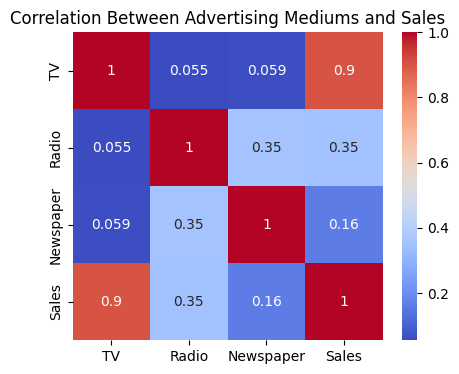


Impact of advertising mediums:
 TV           0.054494
Radio        0.107180
Newspaper   -0.000019
dtype: float64


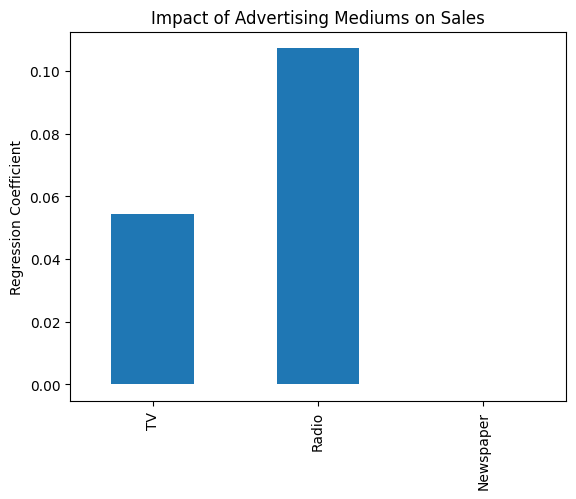

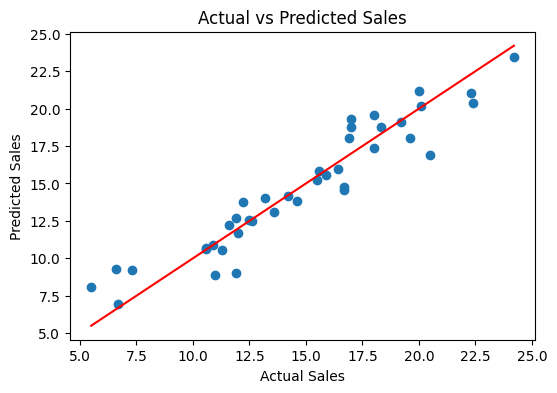


R2 Score: 0.89910282638328
RMSE: 1.4207828467605377

Predicted Sales for TV=200, Radio=40, Newspaper=50: 19.81958409813488

After Normalization:
R2 Score: 0.89910282638328
RMSE: 1.4207828467605377

R2 Score (Radio + Newspaper only): -0.05191341464060373


In [4]:
# ================================
# Sales Prediction using Linear Regression
# ================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# ----------------
# Load Dataset
# ----------------
df = pd.read_excel('/content/drive/MyDrive/ML_Project/advertising_sales_data.xlsx')

# Handle missing values by dropping rows with any NaN values
df.dropna(inplace=True)

print(df.head())
print("\nDataset shape:", df.shape)

# ----------------
# Q1: Average TV advertising spend
# ----------------
avg_tv = df['TV'].mean()
print("\nAverage TV advertising spend:", avg_tv)

# ----------------
# Q2: Correlation between Radio & Sales
# ----------------
radio_sales_corr = df['Radio'].corr(df['Sales'])
print("\nCorrelation between Radio and Sales:", radio_sales_corr)

# Correlation Heatmap
# Correlation Heatmap (SAFE VERSION)
plt.figure(figsize=(5,4))
sns.heatmap(df[['TV', 'Radio', 'Newspaper', 'Sales']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title('Correlation Between Advertising Mediums and Sales')
plt.show()


# ----------------
# Q3: Which medium impacts Sales the most?
# ----------------
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

model = LinearRegression()
model.fit(X, y)

coefficients = pd.Series(model.coef_, index=X.columns)
print("\nImpact of advertising mediums:\n", coefficients)

coefficients.plot(kind='bar')
plt.title('Impact of Advertising Mediums on Sales')
plt.ylabel('Regression Coefficient')
plt.show()

# ----------------
# Train-Test Split
# ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------
# Linear Regression Model
# ----------------
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# ----------------
# Q4: Actual vs Predicted Sales
# ----------------
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

# Model Performance
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nR2 Score:", r2)
print("RMSE:", rmse)

# ----------------
# Q5: Predict Sales for new data
# ----------------
new_data = pd.DataFrame({
    'TV': [200],
    'Radio': [40],
    'Newspaper': [50]
})

predicted_sales = lr.predict(new_data)
print("\nPredicted Sales for TV=200, Radio=40, Newspaper=50:", predicted_sales[0])

# ----------------
# Q6: Effect of Normalization
# ----------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_s, y_train_s)

y_pred_s = lr_scaled.predict(X_test_s)

r2_scaled = r2_score(y_test_s, y_pred_s)
rmse_scaled = np.sqrt(mean_squared_error(y_test_s, y_pred_s))

print("\nAfter Normalization:")
print("R2 Score:", r2_scaled)
print("RMSE:", rmse_scaled)

# ----------------
# Q7: Only Radio + Newspaper
# ----------------
X_rn = df[['Radio', 'Newspaper']]

X_train_rn, X_test_rn, y_train_rn, y_test_rn = train_test_split(
    X_rn, y, test_size=0.2, random_state=42
)

lr_rn = LinearRegression()
lr_rn.fit(X_train_rn, y_train_rn)

y_pred_rn = lr_rn.predict(X_test_rn)

print("\nR2 Score (Radio + Newspaper only):",
      r2_score(y_test_rn, y_pred_rn))